In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from abstract_values.utils.data import BIDS_FOLDER
from abstract_values.behavior.data import FMRISubject

In [2]:
# ── settings ──────────────────────────────────────────────────────────────────
mask     = 'NPCr'
n_voxels = 100

# pil01 = FMRISubject(1), pil02 = FMRISubject(2)
subjects_sessions = [
    ('pil01', 1, 1, 1),   # (pil_subject, pil_session, fmri_subject_id, behavioral_session)
    ('pil01', 2, 1, 2),
    ('pil02', 1, 2, 1),
]

deriv_dir = BIDS_FOLDER / 'derivatives' / 'encoding_models' / 'aprf'

In [3]:
def get_value_to_orientation(fmri_subject_id, behavioral_session):
    """Return arrays (values, orientations) for interpolating value → orientation."""
    s = FMRISubject(fmri_subject_id)
    d = s.get_behavioral_data().reset_index()
    d = d[(d['event_type'] == 'feedback') & (d['session'] == behavioral_session)]
    tbl = (d[['orientation', 'value']]
           .drop_duplicates()
           .sort_values('value'))
    return tbl['value'].values.astype(float), tbl['orientation'].values.astype(float)


def load_fisher_info(pil_subject, pil_session):
    fn = (deriv_dir / f'sub-{pil_subject}' / f'ses-{pil_session}' / 'func' /
          f'sub-{pil_subject}_ses-{pil_session}_task-abstractvalue'
          f'_mask-{mask}_nvoxels-{n_voxels}_desc-fisherinfo_pe.tsv')
    df = pd.read_csv(fn, sep='\t', index_col=0)
    df.index.name = 'value_chf'
    return df['fisher_information']

In [4]:
# ── load and convert to orientation axis ───────────────────────────────────────
records = []
for pil_sub, pil_ses, fmri_id, beh_ses in subjects_sessions:
    fi = load_fisher_info(pil_sub, pil_ses)
    val_grid = fi.index.values.astype(float)
    log_fi   = np.log(fi.values)

    val_nodes, ori_nodes = get_value_to_orientation(fmri_id, beh_ses)
    # Interpolate: for each value in the FI grid, find the corresponding orientation
    ori_grid = np.interp(val_grid, val_nodes, ori_nodes)

    label = f'sub-{pil_sub}  ses-{pil_ses}'
    mapping_name = 'inverse_cdf' if (fmri_id == 1 and beh_ses == 1) else 'cdf'
    print(f'{label} ({mapping_name}):  log-FI peak at {ori_grid[log_fi.argmax()]:.1f}°')

    records.append(dict(label=label, ori=ori_grid, log_fi=log_fi, mapping=mapping_name))

sub-pil01  ses-1 (inverse_cdf):  log-FI peak at 76.8°
sub-pil01  ses-2 (cdf):  log-FI peak at 110.8°
sub-pil02  ses-1 (cdf):  log-FI peak at 90.9°


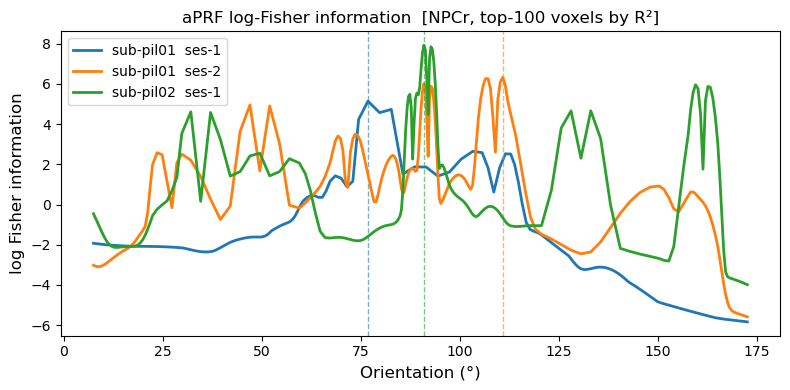

In [5]:
# ── overlay plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = plt.cm.tab10.colors
for i, rec in enumerate(records):
    ax.plot(rec['ori'], rec['log_fi'], lw=2, color=colors[i], label=rec['label'])
    peak_ori = rec['ori'][rec['log_fi'].argmax()]
    ax.axvline(peak_ori, color=colors[i], lw=1, linestyle='--', alpha=0.6)

ax.set_xlabel('Orientation (°)', fontsize=12)
ax.set_ylabel('log Fisher information', fontsize=12)
ax.set_title(f'aPRF log-Fisher information  [{mask}, top-{n_voxels} voxels by R²]', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

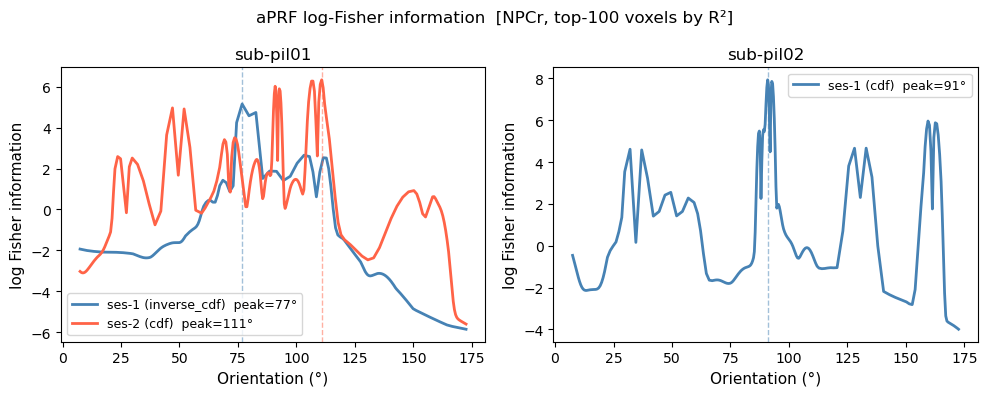

In [6]:
# ── per-subject panels ─────────────────────────────────────────────────────────
pil_subjects = sorted({r['label'].split()[0] for r in records})
fig, axes = plt.subplots(1, len(pil_subjects), figsize=(5 * len(pil_subjects), 4), sharey=False)
if len(pil_subjects) == 1:
    axes = [axes]

ses_colors = {'1': 'steelblue', '2': 'tomato'}

for ax, pil_sub in zip(axes, pil_subjects):
    for rec in records:
        if rec['label'].split()[0] != pil_sub:
            continue
        ses_num = rec['label'].split('ses-')[1].strip()
        color = ses_colors.get(ses_num, 'gray')
        peak_ori = rec['ori'][rec['log_fi'].argmax()]
        ax.plot(rec['ori'], rec['log_fi'], lw=2, color=color,
                label=f'ses-{ses_num} ({rec["mapping"]})  peak={peak_ori:.0f}°')
        ax.axvline(peak_ori, color=color, lw=1, linestyle='--', alpha=0.5)

    ax.set_xlabel('Orientation (°)', fontsize=11)
    ax.set_ylabel('log Fisher information', fontsize=11)
    ax.set_title(pil_sub, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'aPRF log-Fisher information  [{mask}, top-{n_voxels} voxels by R²]', fontsize=12)
plt.tight_layout()
plt.show()